# 计算机图形学笔记

20251114

## 第一章 绪论

### 1. 图像学和图形学的区别

### 2. 走样的原因
  
  用离散量表示连续量引起的失真.
### 3. 反走样的概念
  
  减少或消除因走样造成的阶梯形或闪烁的效果的方法称为反走样.反走样技术有:

  1. 前滤波:以较高的分辨率显示对象
  2. 后滤波:加权区域取样

### 4. 直线的扫描转换算法

对直线进行光栅化时,需要在显示器有限个象素中,确定最佳逼近该支线的一组象素,并且按照扫描线顺序,对这些象素进行写操作.这个过程称为显示器绘制直线或直线的扫描转换.

直线的扫描转换算法有:

- DDA算法
- 中点线算法
- Bresenham算法
  
#### 4.1 DDA算法

考虑到增量计算较快的原因，所以没有直接使用 y = kx+b的方法直接计算每个点的横纵坐标。而是使用 y(i) = y(i-1)+k △x  当△x  = 1的时候  y(i) = y(i-1)+k,这样只需要加法运算就可以求出每次的y值。
#### 4.2 Bresenham算法
  
  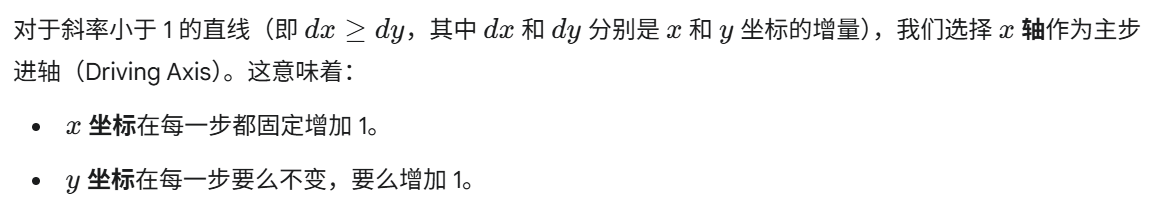

  以此种情况(即dx>dy)为例,每一步x坐标递增之后,y坐标要么不变(水平向右移动),要么以相同幅度递增(对角线方向移动).选择的规则如下:

  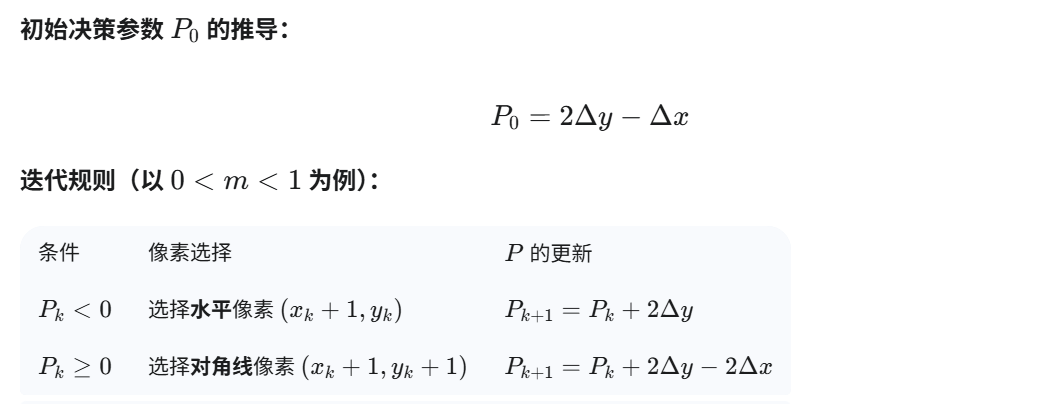

  **注:为了方便计算,可以提前算出两个方向(向右或向右上的)增量.**

  

## 第二章 颜色模型

### 1. 设备无关与设备相关
   - 设备无关的颜色模型:基于人眼对色彩感知的度量建立的数学模型,主要用于计算和测量.
   - 设备相关的颜色模型:以RGB模型为例,一组确定的RGB数值在一个液晶屏上显示,最终会作用到三色LED的电压上.这样一组值在不同设备上解释时,得到的颜色可能不同.
  
### 2. 设备相关与无关的模型例子
  在设备相关,不相关的颜色模型间互相转换,一般是以RGB和CIEXYZ作为桥梁进行的.
  
  - 相关:RGB,CMY,CMYK,HSV
  - 不相关: CIEXYZ

### 3. RGB模型和CMY模型之间的比较

| 比较维度 | RGB (Red, Green, Blue) | CMY (Cyan, Magenta, Yellow) |
| :--- | :--- | :--- |
| **物理原理** | 加色法 (Additive Color) | 减色法 (Subtractive Color) |
| **媒介本质** | 光 (发光体) | 颜料 / 油墨 (吸光物体) |
| **基础底色** | 黑色 (无光) | 白色 (全反射，如白纸) |
| **混合方向** | 颜色越加越亮 | 颜色越加越暗 |
| **最大混合** | R + G + B = 白色 | C + M + Y = 黑色 (理论值) |
| **主要应用** | 显示器、投影仪、相机、手机屏幕 | 打印机、胶印印刷、绘画 |印印刷、绘画、印刷、绘画

## 第三章 物体表示(1)-多边形表示:OBJ,BRep和半边数据结构

### 1.坐标系区别

- 世界坐标系: **场景参照坐标系,一个场景只有一个世界坐标系.** 是用于定义物体在场景中的位置.是一个大范围的参考,用来确定所有物体如何放置在这个虚拟世界中.

- 建模坐标系: **描述单个物体的形状,尺寸所采用的坐标系.** 是针对单个物体的.每个物体都是在它子集的坐标系中被创建和编辑的,就像是每件家具有自己的小平面图.这有助于设计者单独操作和调整每个模型,而不必担心其它模型或整个世界的坐标.

### 2.多边形表示方法:OBJ格式

保存: 1.几何信息.2.纹理信息.3.光线信息.

- 多边形表示的优点:
  + 表示简单.
  + 可以表示具有任意拓扑的物体.
  + 可以表示具有丰富细节的物体.
  + 大部分图形硬件支持多边形物体的加速绘制.
 
- 多边形表示的不足:
  + 逼近表示,难以满足交互时放大需求.
  + 难以用传统方法编辑物体外形.
  + 缺乏解析表达式,几何属性计算困难.
  + 在表示复杂拓扑和具有丰富细节的物体时,数据量庞大,建模/编辑/绘制/存储的负担重.

### 3.BREP表示

实体的边界通常由面的并集来表示;每个面又由他所在的曲面的定义加上其边界来表示,面的边界是边的并集;而边又是由点来表示的.

**BRep是什么?**

A:网格表示数据结构.

**BRep表示的两种类型**

A:1.拓扑信息(即网格之间的关系). 2.几何信息(网格坐标在哪里,大小是多少).

### 4.半边数据结构

- 每条边被记录为两条半边,记录每条半边:
  + 起始顶点的指针.
  + 邻接面的指针.(如果为边界,填充null)
  + (逆时针方向的)下一条半边.
  + 相邻的半边.
  + 前一条半边(可选).
  
- 面:
  边界上的一条半边.

- 顶点:
  + 坐标值.
  + 指向以此为起始端点的半边.

~~~C
struct HE_edge{
    HE_vert* vert; //起始顶点的指针
    HE_edge* pair; //相邻的半边:twin
    HE_face* face; //邻接面的指针
    HE_edge* next; //逆时针方向下一条半边
};
~~~

## 第三章 物体表示(2)参数曲面

### 1.参数表示的优点

- 参数表示是显示的
  - 对每一个参数值,可以直接计算曲面上的对应点.
  - 参数表示的物体可以很方便的转化为多边形逼近表示.
- 曲面上的几何量计算简便
- 特殊形式的参数表示的外形控制十分直观:
  - Bezier,B-样条,NURBS(非均匀有理B-样条)曲线/曲面.
 
### 2.Bezier曲线

实际上就是通过控制点$P_i$和一个基函数(Bernstein)来得到一条曲线的参数表达.

公式如下:
$$
p(t) = \sum_{i = 0}^{n} P_i \cdot B_{i,n}(t)
$$

其中,$P_i$是各个控制点的坐标,i从0取值到n.一共n+1个控制点.基函数B的形式是由n决定的:

$$
B_{i,n} = C_{n}^{i} \cdot {t}^{i} \cdot {(1-t)}^{n-i}
$$

所以,当给定控制点后就可以算出$B_{i,n}$,再和$P_i$相乘求和就得到最终的Bezier曲线参数方程.

该曲线的缺点省略:

- 拼接比较复杂.
- 不能作局部修改.每个B多项式在参数整个区间上都有支撑(都不为0),所以每个控制顶点对整体曲线都有影响.
  
### 3.B-样条曲线

样条spine(分段连续多项式):整条曲线用一个完整的表达形式,但内在的量是一段一段的.段间保持连续性条件.

例如:n+1个点,每两点之间构造一条多项式,n+1个点有n个小区间.

每个小区间构造一条三次多项式,变成n段三次多项式的拼接.段间保持二次连续.这就是三次样条.

比如五个点,构造一个多项式则应该是一个四次多项式.而现在采用样条方式,构造四段三次曲线,段间保持二次连续.

B样条的数学表达式为:

$$
P(u) = \sum_{i=0}^{n} P_i B_{i,k}(u),u \in [u_{k-1},u_{n+1}]
$$

形式上和bezier曲线有相似之处,有两个主要的不同:
- 首先是基函数不再和n有关,而是和k有关.k是刻画次数的,可以是2到控制点个数n+1之间的任意整数.$B_{i,k}(u)$称为k阶B样条基函数.也就是k-1次.
- 其次区间不再是$[0,1]$,而是$[u_{k-1},u_{n+1}]$.

B样条的基函数,最好理解的一种定义是递归定义形式的.
$$
\begin{align}
B_{i,1}(u) &= 
\begin{cases}
1, u \in [u_i,u_{i+1}] \\
0,otherwise.\\
\end{cases} \\
B_{i,k}(u) &= \frac{u-u_i}{u_{i+k-1}-u_i}B_{i,k-1}(u) + \frac{u_{i+k}-u}{u_{i+k}-u_{i+1}}B_{i+1,k-1}(u)
\end{align}
$$

k阶B样条对应节点向量数:$n+k个$
$$
u_0,u_1,...,u_{k-1},u_{k},...,u_{n},...,u_{n+k-1},u_{n+k}
$$

B样条函数定义区间:
$$
u \in [u_{k-1},u_{n+1}]
$$

B样条函数的主要性质:
- 局部性:k阶B样条曲线上的一点至多与k个控制顶点有关.

B-样条曲线类型的划分:

1. 均匀B样条曲线
   
   节点沿参数轴等距分布.即$u_{i+1}-u_i = C(常数) > 0$.

2. 准均匀:首尾重复k次.

### NURBS曲线

1. 改进内容:
   - B-样条曲线不能精确表示二次曲面与平面的交线,如圆锥曲线,而NURBS曲线通过引入权因子解决了这个问题.
2. 改进原理
   - 每个权因子$w_i$对应一个控制顶点,通过调整权因子大小,可以改变曲线与控制顶点的相对位置关系.
   - 当所有$w_i = 1$时,这就是B-样条曲线.
   - 当某个$w_i = 0$时,对应的控制顶点对曲线形状没有影响.
   - 权因子越大,曲线越靠近对应的控制点.当$w_i \to \infty$时,曲线过控制点.

## 第三章:物体表示(3)细分曲面

具体细分规则不要求,知道有哪些细分方法即可.

细分曲面的核心就一个点:细分规则.不同的细分规则,生成的细分曲面外形有区别.常见的细分规则有Catmull-Clark细分,Doo-Sabin细分,Loop细分.

## 第三章:物体表示(4)隐式曲面

### 物体的CSG树表示

- CSG树:通过一系列几何操作将简单的基本体素组合起来.
  - 基本体素:立方体,球,圆柱,圆锥.
  - 几何操作:
    - 布尔运算:并,交,差,补.
    - 几何变换:平移,...
- CSG树:含有丰富的造型信息
  - 物体生成过程
  - 物体表示
- CSG树的缺点
  - 绘制耗时
  - 限制了物体外形的修改
  - 改进:混合表示,将边界表示和布尔运算结合起来,形成一种边界表示和CSG实体表示之间的混合表示.
- 例题:
  
  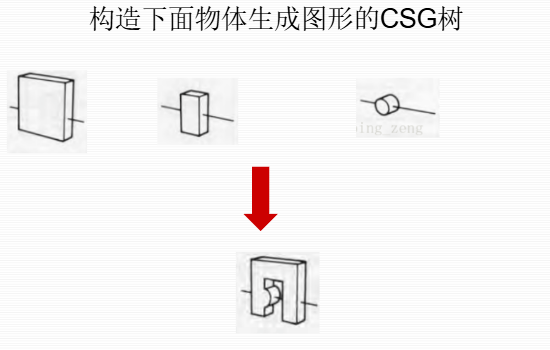
  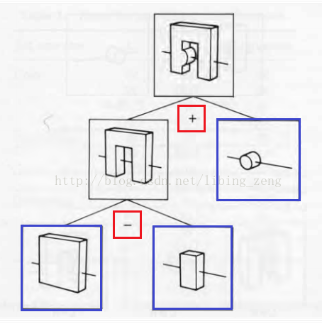

## 第三章:物体表示(5)分形表示

### 分形维数的计算

- 什么是分形几何
  普通几何学研究的对象，一般都具有整数的维数。比如，零维的点、一维的线、二维的面、三维的立体、乃至四维的时空。但是现实生活中象弯弯曲曲的海岸线这些对象就不能用传统欧几里德几何学的整数维描述或者说测量了。

  要描述这一大类复杂无规的几何对象，就引入了分形理论，把维数视为分数维数。

   通俗一点说就是研究无限复杂但具有一定意义下的自相似图形和结构的几何学。 客观事物具有自相似的层次结构，局部与整体在形态、功能、信息、时间、空间等方面具有统计意义上的相似性，称为自相似性。例如，一块磁铁中的每一部分都像整体一样具有南北两极，不断分割下去，每一部分都具有和整体磁铁相同的磁场。这种自相似的层次结构，适当的放大或缩小几何尺寸，整个结构不变。

- 如果某图形是由把原图缩小为1/a的相似的b个图形组成(自相似性),有:

$$
a^D = b,D = \frac{\log b}{\log a}.
$$

这样的关系成立,则称指数D为相似性维数.D可以是整数或分数.例如Koch曲线的分型维数:

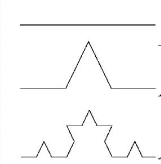

Koch曲线每次迭代的缩放比为3(每条线段都是之前的$\frac{1}{3}$),而每次迭代会产生4条新线段(即原来的一段变成了4个线段的组合).

所以$a = 3 , b = 4$.代入公式中就可以求出该曲线的分形维数:

$$
D_{Koch} = \frac{\log b}{\log a} = \frac{\log 4}{\log 3} \approx 1.26.
$$

**总结:求分形维数关注:1.a的值,也就是缩放比例;2.b的值,也就是产生新结构数量.**

### L-系统:植物建模

- 语法规则:根据语法规则对所给字符进行迭代生成新字符串,每次迭代的结果称为一代.
- 字符解释:将字符串中的字符解释为适当的几何体素.
- 如此就得到一个基于语法规则生成的物体.

#### 一个L-系统实例

- 字符集:$\{A,B,[,],(,)\}$
- 迭代的语法规则:
  - $A \to AA;B \to A[B]AA(B)$
- 字符解释:"A"表示一个主干."B表示一个分支","[]"表示分支向左$45^\circ$,"()"表示分支向右$45^\circ$

假设起始状态为B,迭代的结果是:

- B
- A[B]AA(B)
- AA[A[B]AA(B)]AAAA(A[B]AA(B))

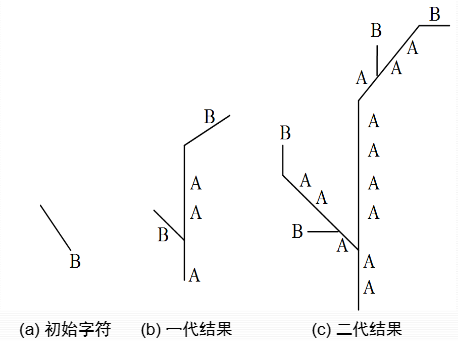

还可以在L-系统中引入更多控制.例如:

- 不同"代"之中字符解释不同.(n+1)代树枝比n代更细更短.
- 终止节点处添加树叶和花.

通过设计不同的语法规则和字符解释集,就可以构造出各种不同植物.

## 第四章 Pipeline

### 1. Rendering Pipeline(渲染管道)

- **考点:掌握图形渲染通道的各部分和作用.**

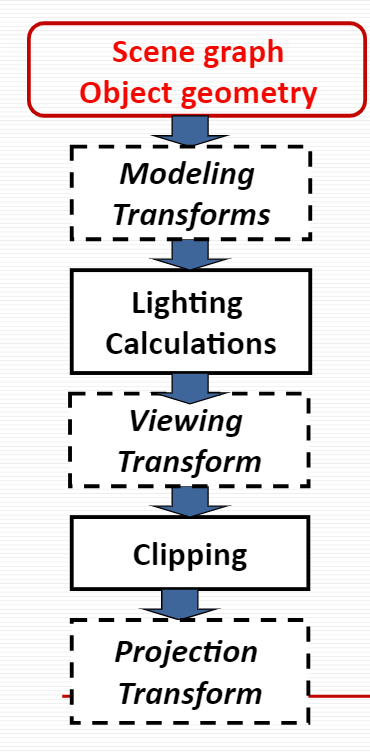

#### Modeling Transforms建模变换
    在建立或编辑三位模型时使用的.这些变换决定了模型的位置,旋转和缩放.可以理解为在虚拟世界中放置和调整模型的过程.

#### Lightning Calculations光照计算
    对场景中的所有几何图元进行照明处理,以模拟现实世界中的光照效果.过程中需要考虑以下几个光照参数:

  + 光源发射(Light source emission):涉及到光源的颜色和强度.包括如何发射光线等.例如点光源,聚光灯或环境光.
  + 表面反射率(Surface reflectance):每种材料不同的发射特性.决定了光线击中表面时反射的量,以及光线反射的方式,例如漫反射或镜面反射.
  + 大气衰减(Atmosphere attenuation):光线在通过介质时的强度减弱程度.
  + 相机响应(Camera response):模拟真实相机对光线的响应,比如光线如何被相机感光元件捕获并转换成图像.
 
    在光照计算过程中通常区分直接照明和全局照明.此处省略.

#### Viewing Transform视图变换
    视图变换的结果是:3D场景转换到视窗/相机坐标系.
    
    这样使得渲染出得图像符合从相机这一特定视角看到的场景.
    
#### Clipping裁剪

    结果:移除视图之外的几何体.

    这样做的好处是提高渲染效率,不必处理那些最终不会出现在最终图像上的数据.

    裁剪通常发生在将三维场景转换到二维图像之前的某个点,确保那些只有能被用户看到的物体才会进入下一步渲染流程.

#### Projection Transform投影转换

    结果:将裁剪后顶点的三维坐标转换为二维屏幕坐标.

    将三维场景的物体映射到二维屏幕上.主要的两种投影方式:

+ 透视投影:这种方式会模拟人眼观察现实世界的效果,远处的物体看起来会更小.
+ 正交投影:这种方式中,所有物体无论远近都保持相同的大小,通常用于工程图纸和建筑设计,因为它可以准确的保持物体的比例和角度.

#### Rasterize光栅化

    在渲染管线中,光栅化Rasterize负责将投影得到的2D图像转换为实际的象素(或点阵图).并确定那些像素将被渲染以及如何渲染.

+ 转换屏幕坐标到像素颜色:这意味着确定由三维物体边缘定义的线条或曲面在屏幕上应该覆盖哪些像素点,并为这些像素点着色.


## 第五章:变换

### 1. 齐次坐标系及其作用

    基本思想是:把一个n维空间的几何问题转换到n+1维空间.从形式上就是用一个n+1维向量表示一个n维空间中的点(向量).

比如:一个二维空间中的点$A(x,y)$的齐次坐标表示为$$(x\ast h,y\ast h,h),\forall h \neq 0.$$

齐次坐标表示不是唯一的.当$h=1$时,称为规格化齐次坐标.

**齐次坐标的作用**:可改写平移变换,缩放变换以及旋转变换为**统一的乘积形式**.

### 2. 二维平移,旋转,缩放矩阵

#### 平移变换

$$
\begin{bmatrix}
x' \\
y' \\
1
\end{bmatrix}
\\=\\
\begin{bmatrix}
1 & 0 & t_x \\ 
0 & 1 & t_y \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$

$$ P'=T(t_x,t_y)\cdot P$$

**注:连续平移Translations是可加的**!即:

$$T(t_x2,t_y2) \cdot T(t_x1,t_y1) = T(t_x2 + t_x1 , t_y2+t_y1)$$

拓展到三维空间(四维)矩阵情况类似.

#### 旋转变换(坐标原点为旋转中心)

$$
\begin{bmatrix}
x' \\
y' \\
1 
\end{bmatrix}
\\=\\
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1 \\
\end{bmatrix}
$$

**注:连续旋转可加**!即:

$$P' = R(\theta_1 + \theta_2) \cdot P$$

拓展到三维空间后,形式根据绕x,y,z轴有所不同.

绕z轴旋转(形式跟2维基本相同):
$$
R_z(\theta) = 
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 & 0\\
\sin\theta & \cos\theta & 0 & 0\\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

绕x轴旋转:
$$
R_x(\theta) = 
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & \cos\theta & -\sin\theta & 0\\
0 & \sin\theta & \cos\theta & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

绕y轴旋转:
$$
R_y(\theta) = 
\begin{bmatrix}
\cos\theta & 0 & \sin\theta & 0\\
0 & 1 & 0 & 0\\
-\sin\theta & 0 & \cos\theta & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

#### 缩放变换

$$
\begin{bmatrix}
x' \\
y' \\
1 
\end{bmatrix}
\\=\\
\begin{bmatrix}
S_x & 0 & 0 \\
0 & S_y & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1 \\
\end{bmatrix}
$$

**注:连续缩放式相乘的**!不是叠加,即:

$$S(S_x2,S_y2) \cdot S(S_x1,S_y1) = S(S_x1 \cdot S_x2 , S_y1 \cdot S_y2)$$

拓展到三维空间类似.

**<mark>注意:因为对坐标变化时,原坐标向量在最右边.所以越先做的变换应该越靠右!!!</mark>**

### 3.模型变换,取景变换,投影变换,设备变换,视窗变换的作用

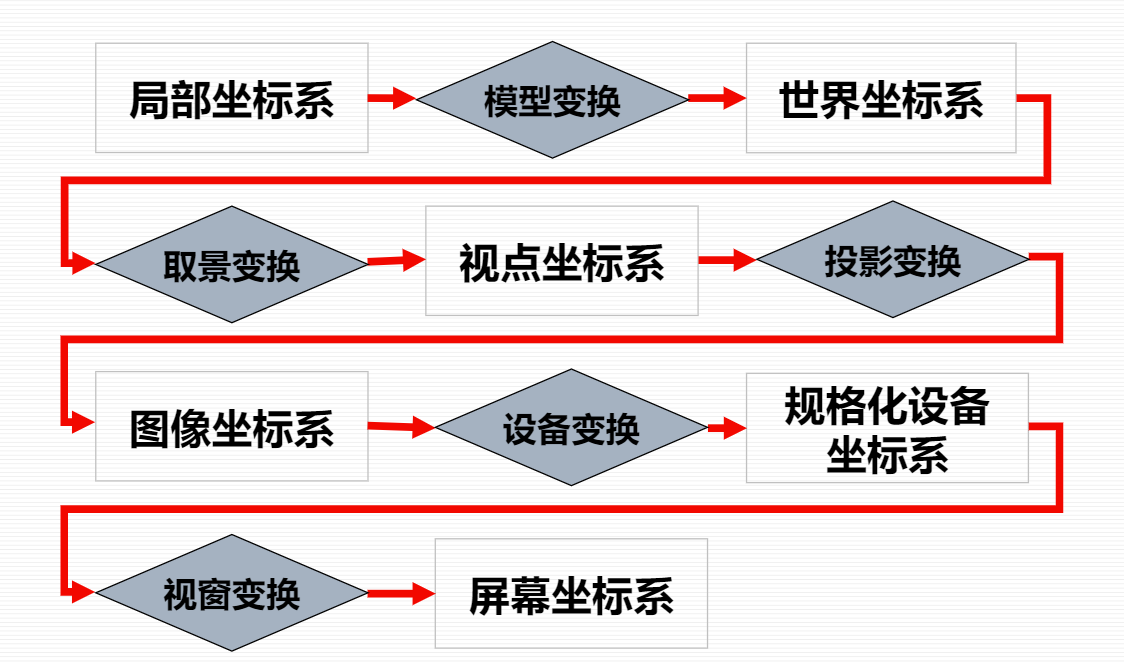

### 4.投影变换

#### 平行投影

略

#### 透视投影

- 灭点:3D物体的一组平行线投影后收敛于一点,称为灭点.
- 主灭点:3D物体**平行于坐标轴的平行线**收敛产生的灭点.
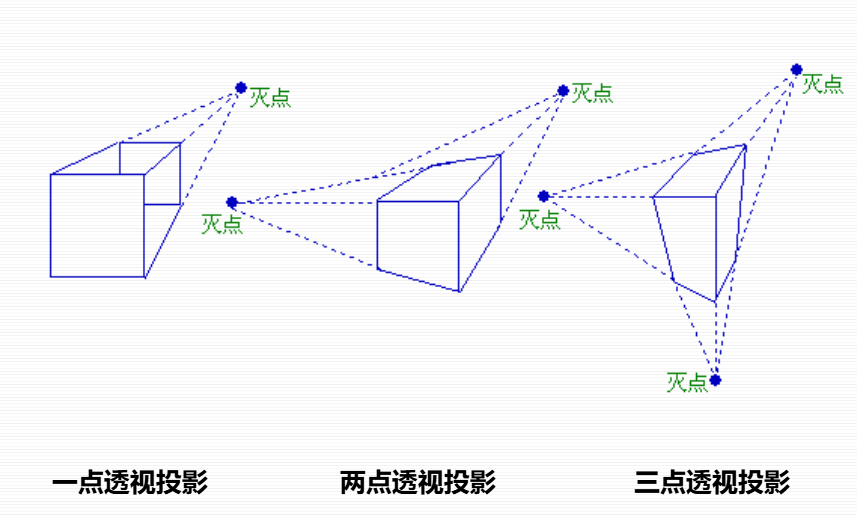

#### 一点,二点,三点透视

##### 一点透视

对变换:
$$ 
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0 \\
p & q & r & 1\\
\end{bmatrix}
\cdot 
\begin{bmatrix}x\\y\\z\\1\end{bmatrix}$$

令$p=r=0$,得到坐标$\begin{bmatrix}x\\y\\z\\qy+1\end{bmatrix}$.

齐次化后,当$y \to \infty$,有坐标$\begin{bmatrix}0\\\frac{1}{q}\\0\\1\end{bmatrix}$.所有点经过变换后均集中于Y轴上一点.称这一点为灭点$\begin{bmatrix}0\\\frac{1}{q}\\0\end{bmatrix}$.

同理,p,q,r分别不为零都有这个结果.

## 第六章:裁剪

### 1.裁剪操作在渲染pipeline中的位置

### 2.直线裁剪算法

#### Cohen-Sutherland裁剪算法

基本思想:对于每条待裁剪的线段$P_1P_2$,分三种情况:

- 若完全在窗口内,显示;
- 若完全在窗口外,丢弃;
- 否则:
  - 求线段与窗口边界的交点,在交点处把线段分为两段.
  - 其中一段在窗口外,丢弃,之后对另一端重复.

编码规则:

$$
\begin{align}
C_t(top) = \begin{cases}
1 & ,if y > y_{max}; \\
0 & ,otherwise.\\
\end{cases}
C_b(bottom) = \begin{cases}
1 & ,if y < y_{min}; \\
0 & ,otherwise.\\
\end{cases}\\
C_r(right) = \begin{cases}
1 & ,if x > x_{max}; \\
0 & ,otherwise.\\
\end{cases}
C_l(left) = \begin{cases}
1 & ,if x > x_{min}; \\
0 & ,otherwise.\\
\end{cases}
\end{align}
$$

对直线段的两端点,编码后:
- 若两端点编码全为0,则该直线段在窗口内,该直线段直接保留.
- 进行逻辑与运算:
  - 结果非0,说明该直线段在窗口外,直接舍弃.
  - 结果为0,需要求该直线和窗口边界的交点.
- 若需要求交:
  - 将两个端点进行逻辑或运算,根据1的位置来确定可能相交的窗口边.
  - 求交按照固定的顺序来,左右下上或上下右左.一条线段与窗口最多求交四次.
 
例如:

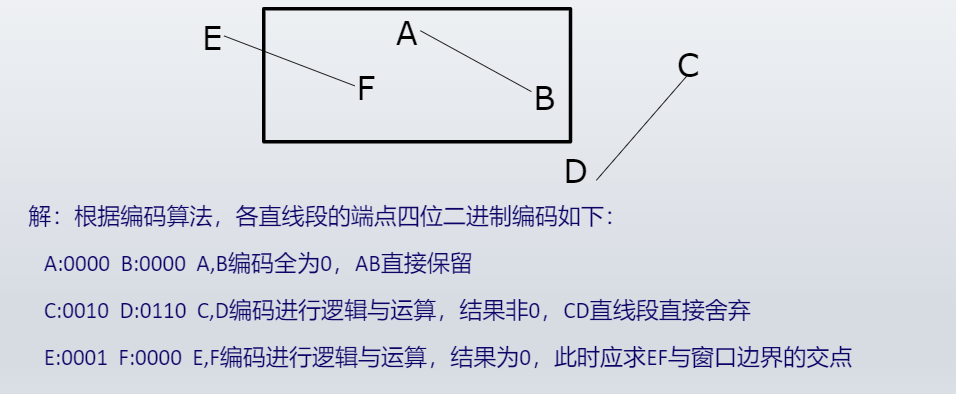

#### 中点分割算法

类似于Cohen-Sutherland算法:

- 将直线两端点$P_1,P_2$编码得到$C_1,C_2$.
- 全为0,说明两端点在窗口内,保留线段.
- $C_1 \& C_2 \neq 0$,表明两端点在窗口外同侧,线段全在窗口外,应该舍弃.
- 否则,求交点并进行裁剪.裁剪一端,得到最近可见点.求最近可见点:<mark>中点分割算法!</mark>
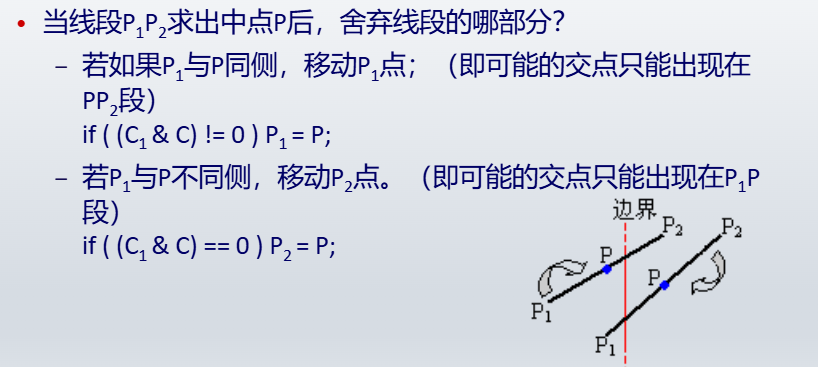
每次将和中点同侧的端点移动到中点处.
如此可收敛到最近可见点,即交点.

中点分割算法的特点:

- 求交点次数(n)于线段长度(L)有关,其关系为$L = 2^n$.例如,线段长度为256,则求交点次数为8.
- 求出的交点为边界上的有效交点,而非边界及其延长线上的交点(Cohen-Sutherland算法得到的交点为此类).
- 求中点:加法与除法,容易硬件实现.

#### 梁友栋-Barsky裁剪算法

对于直线段$P_0(x_1,y_1) \to P_1(x_2,y_2)$,直线上点的参数表示为:
$$
\begin{cases}
x = x_1 + u \ast (x_2 - x_1) = x_1 + u \ast \Delta x \\
y = y_1 + u \ast (y_2 - y_1) = y_1 + u \ast \Delta y
\end{cases}
(0 \leq u \leq 1.)
$$


计算四个交点的p,q,u.公式如下:
$$
\begin{align}
p_1 = -\Delta x, q_1 = x_1 - x_{left} \\
p_2 = \Delta x, q_2 = x_{right} - x _1 \\
p_3 = -\Delta y, q_3 = y_1 - y_{bottom} \\
p_4 = \Delta y, q_4 = y_{top} - y_1 \\
\end{align}
$$

- 当$p_i < 0$时,线段从裁剪边界的外部到内部:即这条边界为始边/入边.反之为终边/出边.
- 当$p_i = 0$时:
  - 若$q_i < 0$, 则$P_0pP_1$完全不可见.
  - 若$q_i > 0$,则$P_0P_1$平行于裁剪边界,并且至少部分在窗口内.

例如,当$\Delta x \geq 0$, 对于左边界,$p_1 < 0$,应该从左边界外部到内部,即左边界为入边.

边界交点的参数:
$$
u_i = \frac{q_i}{p_i},p_i \neq 0.
$$

最终,在入边交点,即$p_i < 0$的点中,取u最大的点.在出边交点,即$p_i > 0$的点中,取u最小的点.就得到这条直线段裁剪后的两个端点.再将该u值代入直线的参数方程中,就可以得到最终两个端点的坐标.

- 特点
  - 通常比Cohen-Sutherland算法效率更高.这种算法每次求交都要作除法.
 
#### 多边形裁剪
 
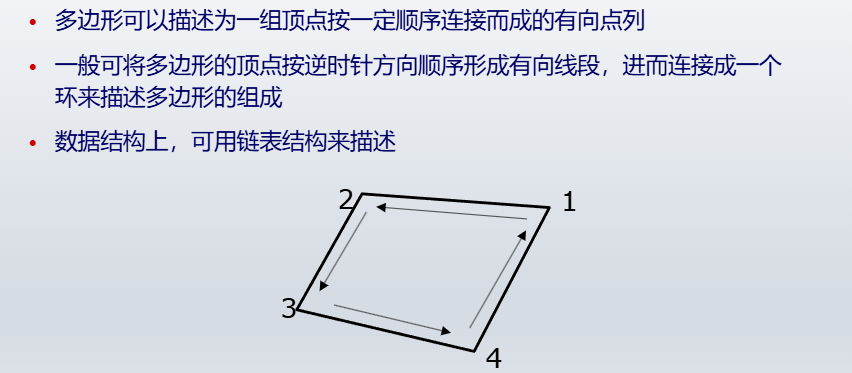
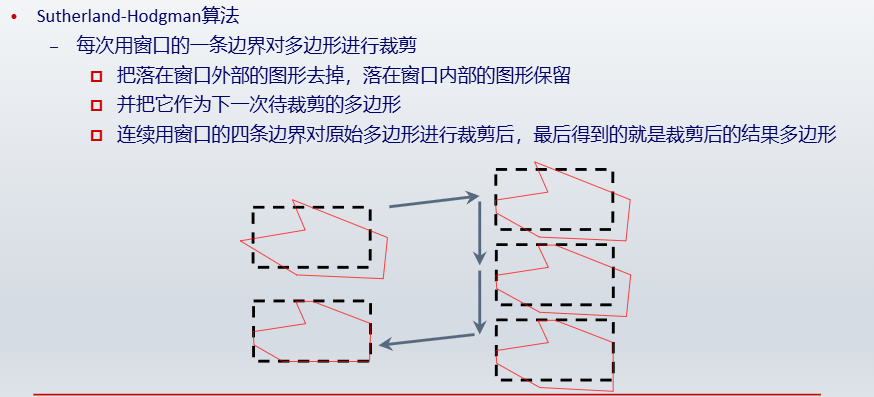
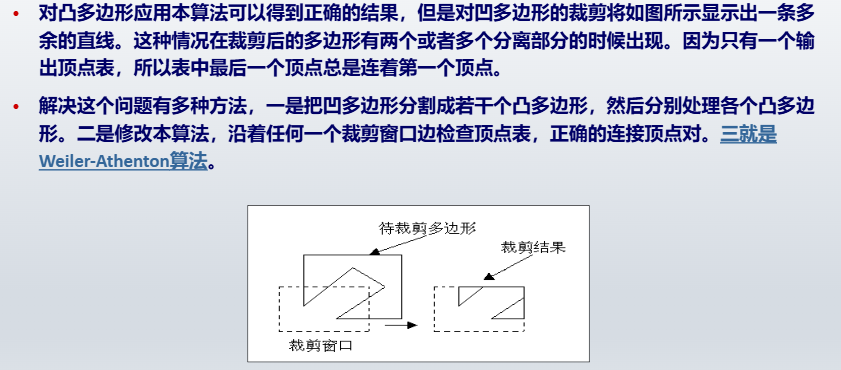

##### WA任意多边形裁剪算法

| step i | 内容|
| --- | -----------|
| 1 | 顺时针输入待裁剪多边形顶点序列I到数组1中. |
| 2 | 顺时针输入待裁剪窗口顶点序列II到数组2中. |
| 3 | 求出所有交点,并标注出该交点是"入"还是"出".然后将交点按照顺序插入序列I得到新的序列III,放入数组3中.同样将交点按顺序放入序列II得到序列IV,放入数组4中.|
| 4 | 初始化输出数组Q,令其为空.接着从数组3(插入了交点的多边形顶点序列)中寻找入点.若没有入点,$end!$.|
| 5 | 如果找到入点,将入点放入s中暂存.|
| 6 | 将入点记录到Q中,并从数组3中将该点的入标记删去.|
| 7 | 按照数组3顺序取顶点:$\begin{cases}如果顶点不是出点,则将顶点录入到数组Q中,goto \ step 7.\\else,goto \  step 8.\end{cases}$|
| 8 | 按照数组4顺序取顶点:$\begin{cases}如果顶点不是入点,则将顶点录入到Q中,goto \ step 8.\\else,goto \  step 9.\end{cases}$ |
| 9 | $\begin{cases}如果顶点不等于起始点s,goto \ step 6, 继续跟踪数组3.\\else,输出数组Q,goto \  step 4(可能结束,也可能找到下一个窗口内的多边形).\end{cases}$ |

注意:
- step 7,step 8的顶点顺序再步骤跳转时会继承.例如再第七步取到顶点b,此时b是出点,故跳转到第八步,依照数组4的顺序**从b开始**继续取顶点.
- 裁剪窗口顶点一定不是出点或者入店,所以遇到窗口顶点都会加入Q中.
- 3遇到不出加,4遇到不入加.否则跳.
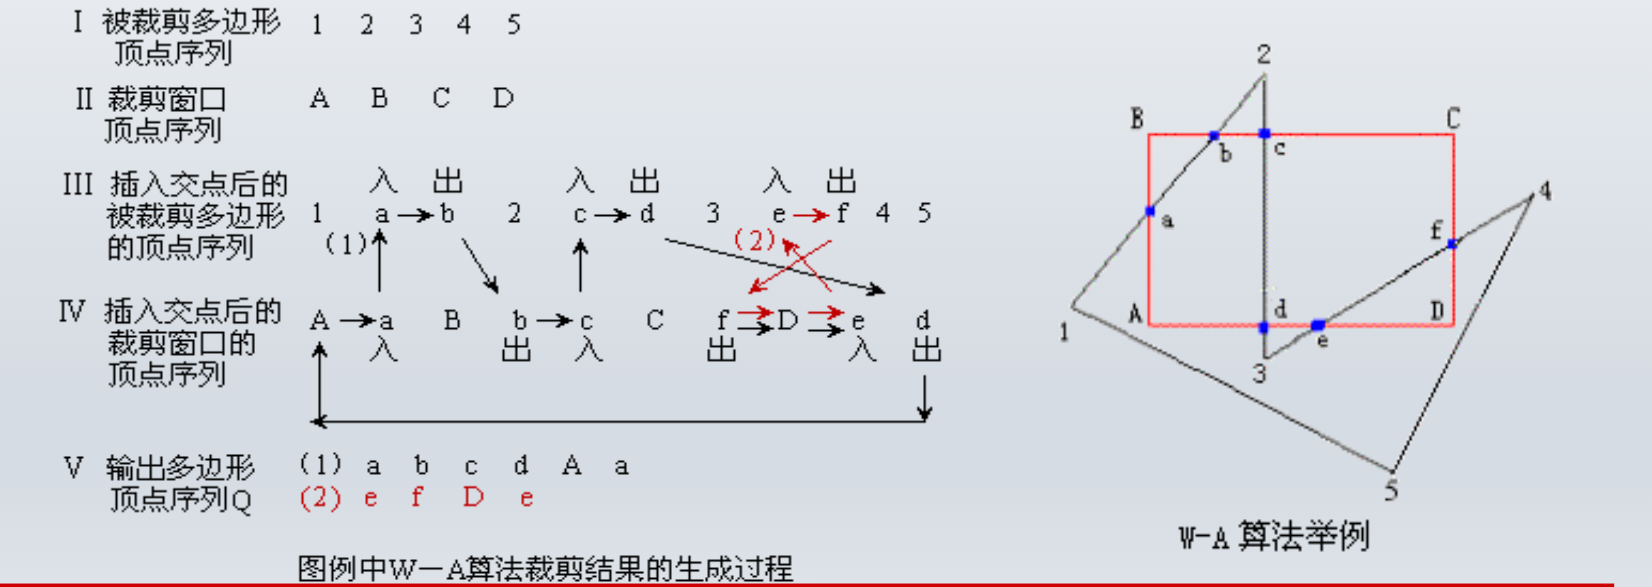


## 第七章:光栅化

多边形的两种表示方式:

- 顶点表示:用多边形的有序顶点序列表示多边形.
  - 优点:
    - 直观
    - 几何意义明显
    - 存储量小
  - 不足:
    - 难以判断哪些像素位于多边形内部
    - 不能直接用于多边形着色
- 点阵表示:用多边形内部像素集合来表示多边形.
  - 优点
    - 便于用帧缓冲器(frame buffer)表示图形.
    - 面着色所需的图形表示.
  - 缺点
    - 丢失了几何信息
    - 占用存储空间多.

多边形的扫描转换:

- 作用:把多边形的顶点表示转化为点阵表示.
- 从多边形的给定边界出发,求出内部的各个像素.
- 并给帧缓冲器中各个对应元素设置相应灰度或颜色.

### 1. 区域填充算法

区域的定义:已经表示成点阵的像素集合.

区域的表示:

- 内部表示:把区域内的像素枚举出来.
  - 区域内所有像素着同一种颜色.
  - 区域边界像素不能着上述颜色.
- 边界表示:把区域边界上的像素枚举出来.
  - 边界上所有像素都着同一种颜色.
  - 区域内部像素不能着上述颜色.

内部表示区域种子填充算法:

- 假设内部表示区域为$G$,其中像素原有颜色为$G_0$,需要填充的颜色为$G_1$.
- 算法需要提供一个种子点$(x,y)$,它的颜色为$G_0$.
- 四连通区域的算法如下(左上右下):
  
~~~C
Flood_Fill_4(x, y, G0, G1){	
    if(GetPixel(x,y) == G0 ) // GetPixel(x,y) 返回(x,y)的颜色
                             // 如果已经涂色,此时返回G1,则不会再次涂色.
    {		
        SetPixel(x, y, G1);  //将(x,y)的添上颜色G1	    	
        Flood_Fill_4(x-1, y, G0, G1);		
        Flood_Fill_4(x, y+1, G0, G1);		 		
        Flood_Fill_4(x+1, y, G0, G1); 		
        Flood_Fill_4(x, y-1, G0, G1);	
    }
}
~~~

可以看作按照给定顺序入栈,在出栈时涂色.涂色时再将被涂色块四个方向的像素入栈(若已经涂色则不用入栈). 
注意:上述说法似乎有问题.

下面是边界表示区域种子填充算法(四连通):
~~~C++
void Fill_B_4C(x, y, BC, IC){   //(x,y)种子像素的坐标;BC,边界颜色,IC内部颜色
    if(GetPixel(x,y) != BC && GetPixel(x,y) != IC){//不是边界且没有涂色
        SetPixel(x,y,IC);  //把(x,y)填充成内部颜色.
                           //下面递归调用函数来完成四个方向上的填色.
        Fill_B_4C(x-1, y, BC, IC);
        Fill_B_4C(x, y-1, BC, IC);
        Fill_B_4C(x+1, y, BC, IC);
        Fill_B_4C(x, y+1, BC, IC);
    }
}
~~~


### 多边形的扫描转换

#### 逐点判断算法:逐个像素判别其是否位于多边形内部.
- 判断一个点是否位于多边形内部: <font color="red">射线法</font>
  - 从当前像素发射一条不经过顶点的射线,计算射线与多边形的交点个数.
    $$
    \begin{cases}
    有奇数个交点 \to 在内部. \\
    有偶数个交点 \to 在外部. \\ 
    \end{cases}
    $$

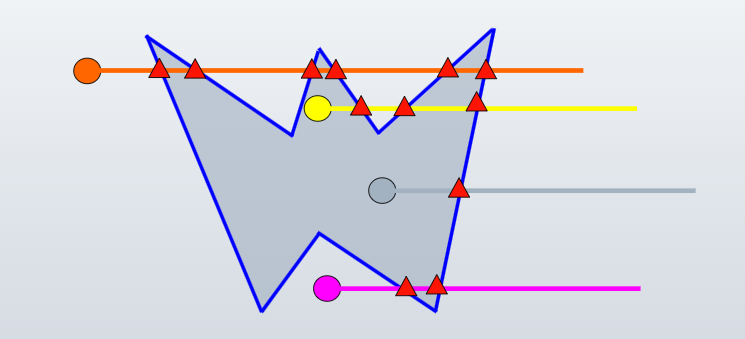

#### 扫描线算法

- 区域连贯性
  - 区域的连贯性是指多边形定义的区域内相邻的像素具有相同的性质.例如具有相同的颜色:
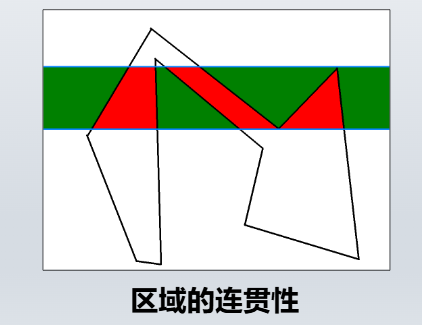

  - 两条扫描线之间的长方形区域被所处理的多边形分割成若干梯形(三角形可以看作退化梯形)。梯形的底边为扫描线，梯形的腰为多边形的边或窗口边缘。
  - 梯形分为两类：多边形内部和多边形外部。两类梯形在多边形内部相间排列(相邻的两个梯形必然有一个位于多边形内部，有一个在多边形外部)。
 
- 扫描线连贯性
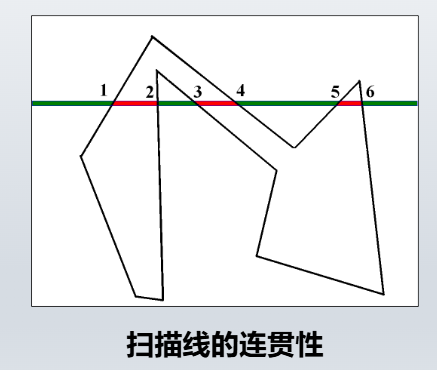
  - 交点序列:扫描线与多边形的交点个数为偶数.
  - 区间相间排列.

- 边的连贯性
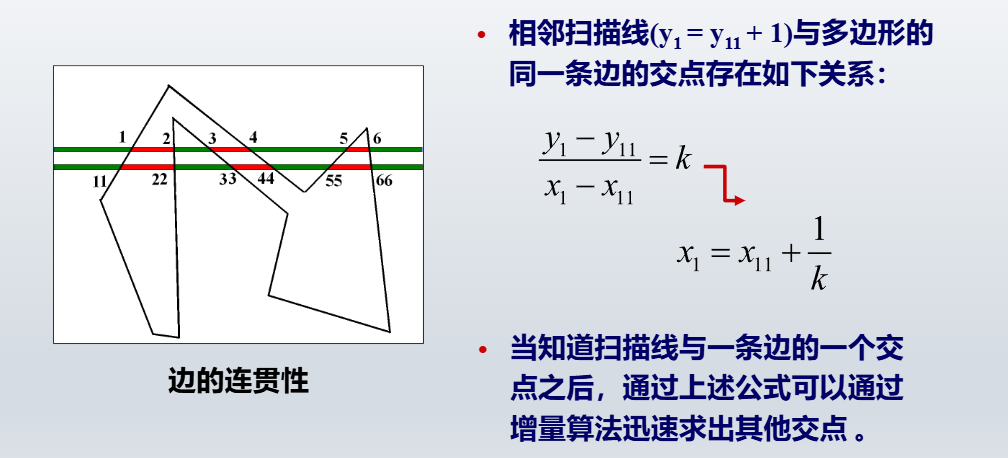

- 奇异点
 - 定义:扫描线与多边形交于多边形的顶点.
 - 计数规则:
$$
\begin{cases}
交点是极值点(包括交点在内的三个相邻顶点都在扫描线同侧) \to 计为两个交点 \\
otherwise \to 计为一个交点.\\
\end{cases}
$$

- 算法核心思想(从下到上扫描)

  - 计算扫描线$y=y_{min}$与多边形的交点,通常这些交点由多边形的顶点组成.
  - 根据<font color="red">边的连贯性</font>,按照从下到上的顺序求得各条扫描线的交点序列.
  - 根据<font color="red">区域和扫描线的连贯性</font>判断位于多边形内部的区段.
  - 对内部直线段进行着色.

为了实现上述四项,算法中需要采取灵活的数据结构.

- 分类的边表ET(Sorted Edge Table):记录多边形信息.
- 活化边链表AEL(Active Edge List):记录当前扫描线信息.

它们的共同基础是边的数据结构.


~~~C
struct edge{
    int y_max; //边的上端点的y坐标
    int x;  //边下断点的x坐标.
            //在AEL中,表示扫描线与边的交点的x坐标
    float dx; //边的斜率的倒数
    struct edge* next;
};
~~~

- 分类的边表(ET)是按边的下断点的y坐标对非水平边进行分类的指针数组.
  - 下端点$y = i$的边,归入第i类;
  - 同一类中,各边按x递增(x相等则按照dx的值排序)的顺序排成一行.
  - 水平边不加入ET.
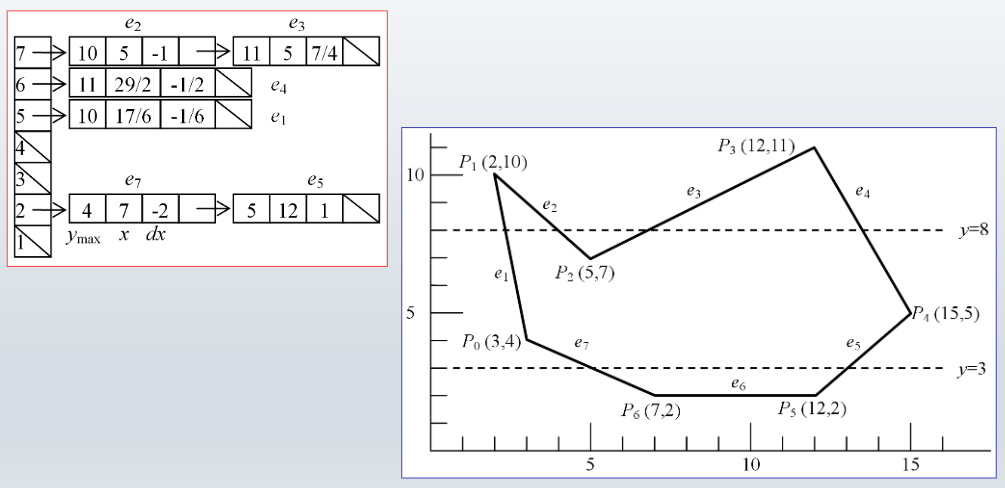

- 活化边链表(AEL)由与当前扫描线相交的边组成.

  - 记录了多边形的边沿扫描线的交点序列.
  - 根据边的连贯性不断刷新交点序列.
  - 基本单元是与扫描线相交的边.
  - 分类边表ET记录初始状态.活化边表AEL随扫描线的移动动态更新.
  - 注意在AEL中,x不再代表相交的边下端点的x坐标,而是代表<font color = "red">交点的x坐标</font>.
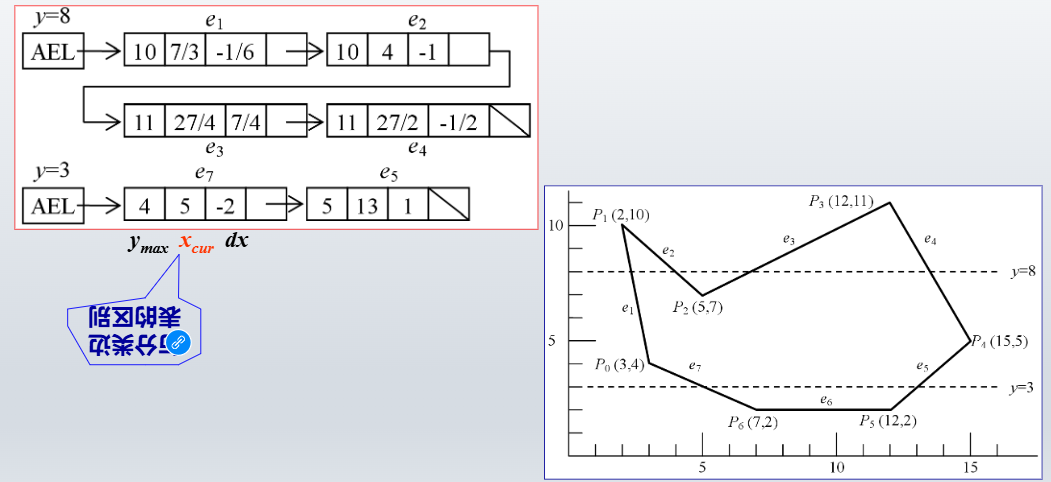

- 多边形扫描转换算法步骤

  1. (y初始化)取扫描线纵坐标y的初始值为ET中非空元素的最小序号.例子中y=2.
     
     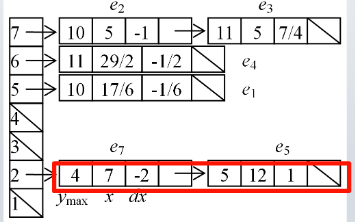
     
  2. (AEL初始化)将边的活化链表AEL设置为空.
  3. 按从下到上的顺序对纵坐标值为y的扫描线(当前扫描线)执行如下步骤,直到分类边表ET和边的活化链表AEL都变成空为止.
     1. 如果ET中第y类元素非空,则将属于该类中所有边从ET中取出(并删除),并插入AEL中.
     2. 对当前扫描线,边的AEL非空,则将AEL中边交点两两依次配对.每一对边与当前扫描线的交点区间位于多边形内部,并对这些区间上的像素着色.
     3. 将AEL中满足$y = y_{max}$的边删除.
     4. 将AEL中剩下的每条边x加dx,即$x' = x + dx$.
     5. 将当前扫描线纵坐标y加1,即$y' = y + 1$.

多边形扫描转换的优点:

- 充分利用多边形区域,扫描线及边的连贯性,避免了反复求交的大量运算.

不足:

- 算法的数据结构和程序结构复杂.
- 对各种表的维持和排序开销大,适合软件实现而不适合硬件实现.

<font color = "red">注:过极值点时,上方看作断开纵坐标一单位长度.同时x坐标也要相应变化!这点在ET和AEL中都要注意!!!</font>

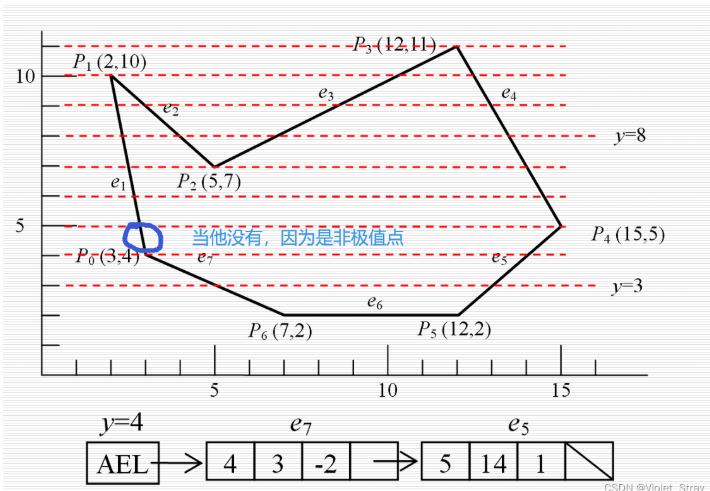


## 第八章:消隐

### 1.图像空间消隐算法

~~~C
for (each pixel in the image){
    connect the pixel and the viewpoint find the nearest object;
    compute the color of that pixel;
    }
~~~

- 受分辨率限制
- 时间复杂度$O(nN)$:
  - 每个像素都需要对物体排序,
  - n:多边形数;
  - N:像素个数;
- 此类算法:z-buffer,scan line algorithm

### 2.对象空间消隐算法

~~~C
for (each object in world coordinate space){
    1. detemine its portion which does not occluded by others;(确定未被遮挡的部分)
    2. find the pixel using scan conversion algorithms;
    3. compute the color of the pixels;
    }
~~~

- 适合精密CAD工程领域
- 复杂度$O(n^2)$
  - n:对象数
- Back surface culling
- 画家算法:
  - 1.排序:将所有要绘制的物体按照到观察者的距离排序.
  - 2.逐个绘制:从远到近绘制物体.因此靠近的(可见的)会遮盖较远的物体.

### Z-buffer算法

~~~C
1. 初始化背景色c-buffer; // 这是屏幕上每个像素的颜色存储区.初始被清空或设置为背景色.
2. 初始化z-buffer; // 这是一个与颜色缓冲区大小相同的数组.
                    // 记录每个像素点的深度z.表示离观察者的远近.
                    // 初始被设置为最大值,表示最远距离.
3. for(每个多边形F){
    for(F中每一个像素(x,y)){
        计算z(x,y); //算出z值:深度
        if(z(x,y) < z-buffer(x,y)){ //当前像素z值更小,说明更近
            c-buffer(x,y) = 计算光亮值属性; //修改c-buffer
            z-buffer(x,y) = z(x,y); //更新z-buffer
        }
    }
}
~~~

计算z值的方法如下:公式形式类似相似三角形比例关系写法.
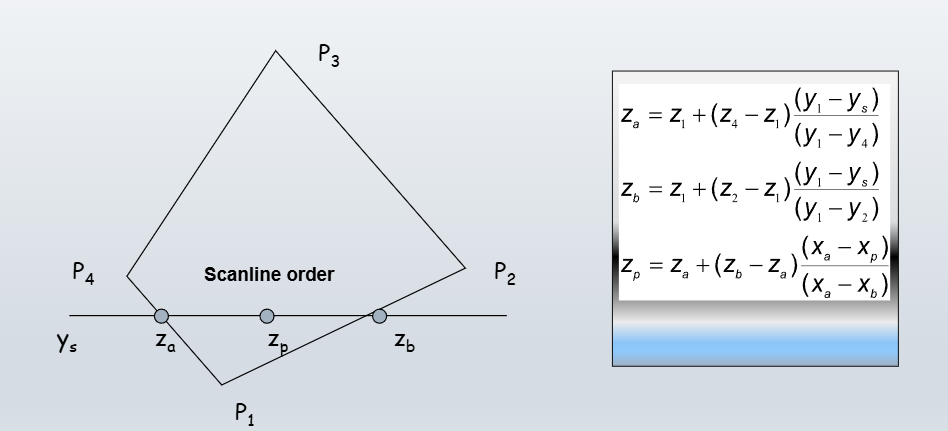

优缺点:
- 复杂度:$O(nN)$.
- 不需要物体排序.
- 能够处理任意几何形状.
- 可以使用硬件加速.
缺点:
- Z-buffer很大.占用显存.
- 受限分辨率,存在走样
- 不好处理透明物体

### 二叉空间剖分树(Binary Space Partitioning)(BSP树)

- 如果场景中的多边形可以被一个平面分割成两部分,<font color = "red">与视点同侧的物体不会被与视点异侧的物体遮挡</font>
- 对位于分割平面两侧的多边形继续进行递归分割,直到一个分割平面两侧或一侧只有一个多边形.
- 适用于视点变化场景不变的绘制.

用两个例子来说明BSP树的结构.

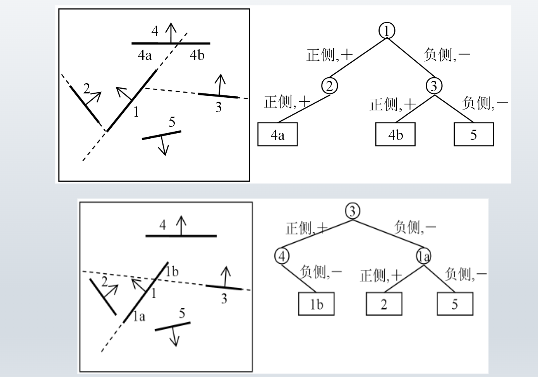

在得到了场景的BSP树之后,遍历BSP树进行绘制.可以从后往前绘制,也可以从前往后绘制.

如果从前往后绘制,则被绘制的像素不再次被上色.

从后往前,相当于在每个子空间里使用画家算法.

~~~C
void showBSP(viewer,T){
    if(T is empty)
        return;
    P = root of T;
    if(viewer is in front of P){
        showBSP(viewer,back subtree of T);
        draw P;
        showBSP(viewer,front subtree of T);
    }else{
        showBSP(viewer,front subtree of T);
        draw P;
        showBSP(viewer,back subtree of T);
    }
}
~~~

##  第九章 真实感图形(1)光照与明暗

### 光照明模型

#### 1. 泛光模型

假定:环境反射光沿任何方向对任何物体表面入射的光亮度都相等,采用常量近似.

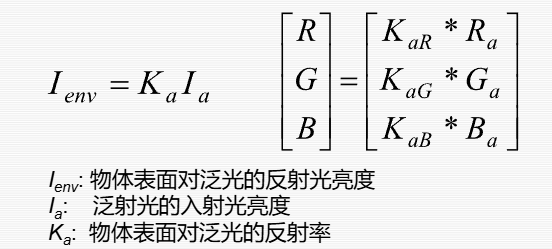

#### 2. Lambert漫反射模型

- 直接光源对物体表面的照射有方向性.
- 物体表面的反射光分为:
  - 漫反射光
    
    漫反射光是物体表面对入射光线朝各个方向的均匀反射.
    - 大小只与入射光的光亮度和入射方向有关
    - 与漫反射光的反射方向无关(均匀)
      
  - 镜面反射光
- 漫反射光亮度和光源入射角的余弦成正比:
  $$
  \begin{align}
  I_d &= K_d I_e \cos\alpha \\
  I_d&:表面漫反射光的光亮度.\\
  K_d&:物体表面漫反射率.\\
  I_e&:入射光的光亮度.\\
  \alpha&:入射角.\\
  \end{align}
  $$

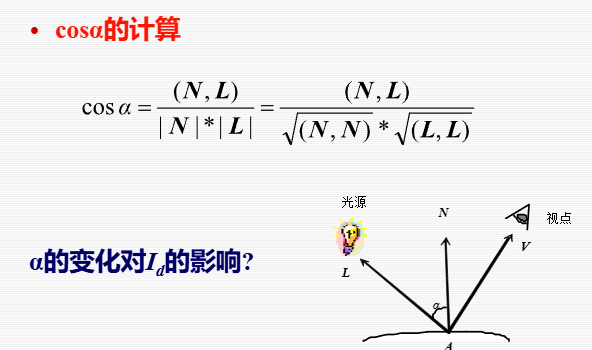

- Lambert光照模型

  $$
  I = K_aI_a + K_dI_e\cos\alpha
  $$

#### 3. Phong模型

- 镜面反射光:
  - 一种朝一定方向的反射光,它遵从光的反射定律.

- Phong采用余弦函数的幂次来模拟镜面反射光:

  $$
  I_s = K_s I_e \cos^n \theta
  $$

  - $I_s$:物体表面镜面反射光亮度.
  - $I_e$:发自光源的入射光的光亮度.
  - $\theta$:镜面反射和视线方向的夹角.
  - $K_s$:表面的镜面反射率.
  - $n$:镜面反射光的会聚指数,又称"高光指数".

- Phong模型:综合了漫反射,.镜面反射和泛光反射
    $$
   I =  K_aI_a + K_dI_e\cos\alpha + K_s I_e \cos^n \theta
    $$

  1. 环境光照(Ambient Lighting)
     - $K_a$:表面对环境光的反射率.
     - $I_a$:环境光照强度.
  2. 漫反射(Diffuse Reflection)
     - $K_d$:表面对漫反射的反射率,或称为漫反射系数.
     - $I_e$:入射光强度.
     - $\cos\alpha$:**入射光和表面法线的夹角的余弦**.这一项决定漫反射的强度.角度越小,漫反射越强.
  3. 镜面反射(Specular Reflection)
     - $K_s$:表面对镜面反射的反射率,或称为镜面反射系数.
     - $I_e$:入射光强度.
     - $\cos^n\theta$:**观察者方向和反射光线夹角**的余弦的n次方(或者**虚拟镜面法向和表面法相的夹角$\gamma$**).这一项越大,高光区域越小,越亮.

#### 局部光照明模型的局限
- 仅考虑从光源直接发出的光线对物体表面光亮度的贡献.
- 没有考虑光线在物体之间的相互反射和透射.
- Whitted模型:整体光照模型
  - 模拟现实世界中景物表面之间的镜面反射和透射现象.

#### 4. Whitted模型

- 假设从某一观察方向V所观察到的物体表面某点P的光亮度的贡献来自于三个方面:
  - 由光源直接照射引起的反射光亮度$I_c$
  - 镜面反射光
  - 规则透射光
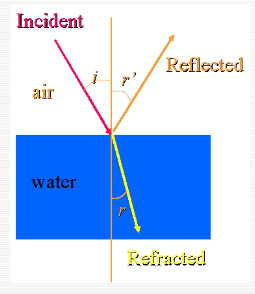

- Whitted整体光照明模型:

  
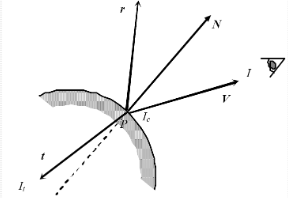
$$
\begin{align}
& I = I_c + k_sI_s + k_tI_t \\
& I_c:由光源直接照射在表面上引起的反射光亮度.\\
& I_s:沿V的镜面反射方向r入射到表面上的*在表面上产生的镜面反射光.\\
& I_t:沿V的规则透射方向t入射到表面上的环境光产生的规则透射光.\\
& k_s:镜面反射率.\\
& k_t:透射率.\\
\end{align}
$$


### 多边形物体的明暗处理(Shading)

- 三类常用的明暗处理方式
  - Flat Shading
  - Gouraud Shading
  - Phong Shading

#### Flat Shading
- 方法
  - 依据局部光照明模型按每一个多边形的法向计算出一个颜色值C.
  - 将C赋给该多边形在屏幕上的投影所覆盖的全体像素.
- 优缺点
  - 处理简单,计算量小.
  - 景物表面上相邻的多边形之间颜色差异较大,存在马赫带效应.

#### Gouraud Shading
- 方法
  - 为多边形物体每一个顶点赋一个法向量.
  - 利用局部光照明模型计算每一个顶点的光亮度.
  - 多边形内部各点处的光亮度值通过<font color = "red">对顶点处的光亮度双线性插值得到.</font>
  - 又称为光亮度插值明暗处理.
- 优缺点
  - 简单快速,较Flat Shading有较大的提升.
  - 马赫带效应任然存在.
  - 不能正确模拟高光.

#### Phong Shading
- 方法
  - 为多边形物体每一个顶点赋一个法向量.
  - 多边形内各点处的法向量通过对多边形顶点处法向量双线性插值得到.
  - 利用Phong模型计算每一点的光亮度.

## 第九章 真实感图形(2)光线跟踪

### 算法原理
- 对每一个像素,执行:
  1. 从视点出发通过该像素中心向场景发出一条光线R，并求出R与场景中物体的全部交点；获得离视点最近交点P；并依据局部光照明模型计算P处颜色值Ic (光线投射).
  2. 在P处沿着R镜面反射方向和透射方向各衍生一条光线.若点P所在表面非镜面或不透明体，则无需衍生出相应光线.
  3. 分别对衍生出的光线递归地执行前面步骤，计算来自镜面反射和透射方向上周围环境对点P光亮度的贡献Is(镜面反射光)和It(规则透视光).
  4. 依据Whitted光照明模型即可计算出点P处的光亮度，并将计算出的光亮度赋给该像素.
- 光线树
  - 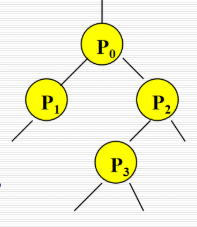
  - 树的结点代表物体表面与跟踪线的交点.
  - 结点连线代表跟踪线.
  - 结点的左孩子代表**反射**产生的跟踪线(r).
  - 结点的右孩子代表**透射**产生的跟踪线(t).
  - 空箭头表示射出场景.
  - $P_0处的光强是P_0,P_1,P_2,P_3点光强的合成.$
  - 计算方法:后序遍历,在每个结点处递归调用光照模型,算出跟踪射线方向的光强,并按两表面之间的距离进行衰减后,传递给父结点.如此最后得到$P_0$,也即屏幕像素处的光强.
  - 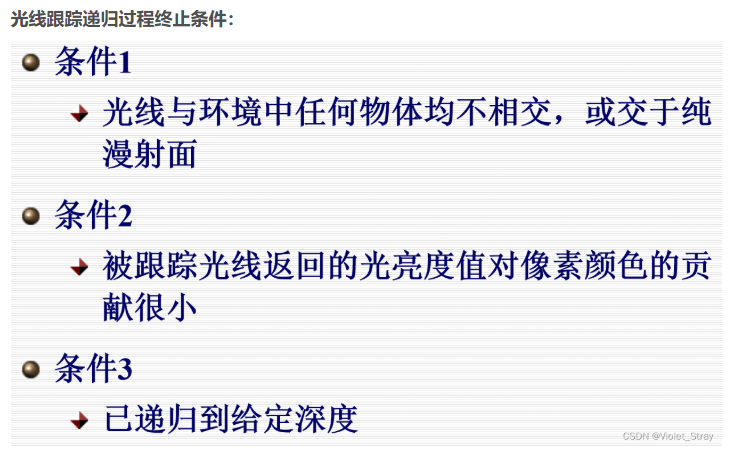
  - 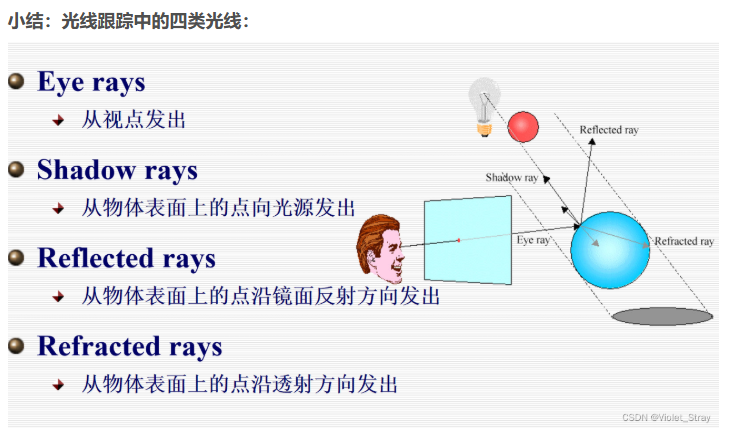

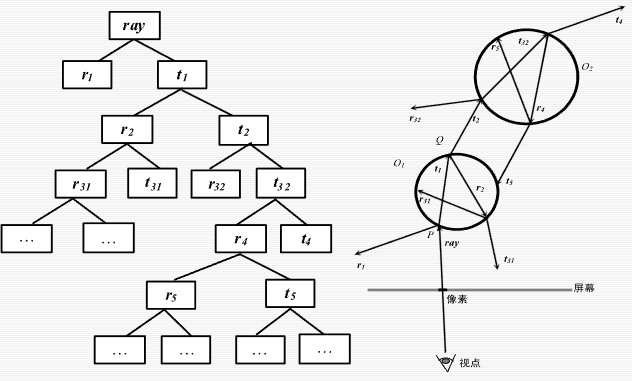
### 反走样

- 引起走样的原因:光线跟踪算法本质上是对画面的点采样.

- 反走样处理方法:
  - 超采样:
    - 超采样是一种直接而有效的方法,它通过在一个像素内部取多个样本点,计算这些样本点的颜色值,然后将这些颜色值平均化得到最终的结果.
    - 简单来说,就是以比屏幕分辨率更高的分辨率来渲染图像,然后将这个高分辨率的图像缩小以适应屏幕分辨率.这样每个像素的颜色都是由多个更小的单元的颜色混合而成的,从而减少了锯齿效果.
  - 自适应超采样:只会在图像中可能出现走样的区域(例如边缘)进行超采样.会先检测图像的哪些部分可能产生走样,只对这些部分进行超采样.

### 加速光线跟踪的技术

#### 1. 包围盒技术

- 为复杂的几何形状创建一个简单的外部容器"盒子".
- 在光线跟踪时,首先检测光线是否与这个简单的盒子相交.如果光线与盒子不相交,那么就可以确定光线也不可能与盒子内部那个更复杂的几何形状相交.如果相交,才进行更复杂的交点计算.
- 这样就可以快速排除很多不可能的情况,只对可能相交的光线进行交点计算.
- 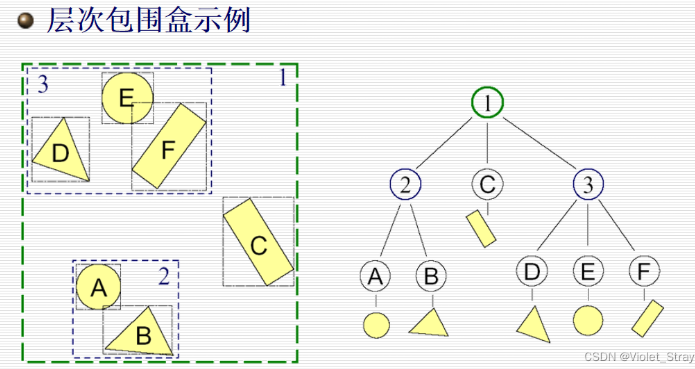

#### 2. 空间分割技术

- 这种技术将整个场景划分为许多小区域,对每个区域内的对象进行管理.
- 当光线穿过场景时,只需要检查光线所经过的具体小区域内的对象,而不是场景中的每一个对象.
- 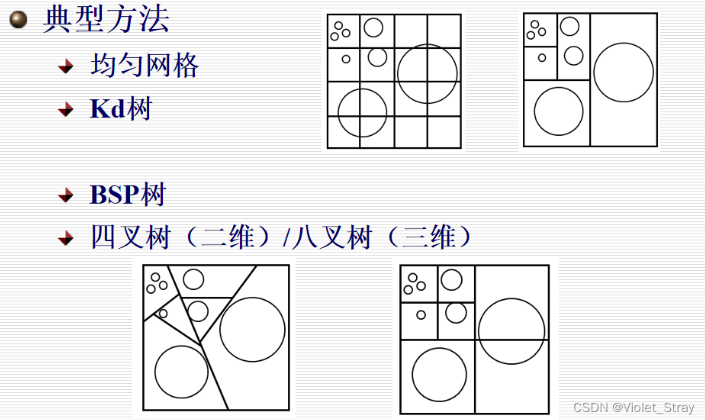

## 第九章 真实感图形(3)纹理映射

### 纹理分类:
- 根据定义域:
  - 二维纹理
  - 三维纹理
- 根据纹理的表现形式
  - 颜色纹理
  - 几何纹理
  - 过程纹理

### 纹理映射:

采用景物表面的参数化表示来确立表面的纹理映射坐标,即可实现纹理图像在景物表面的映射.
- 景物表面参数化为$f(u,v)$
- 纹理图像表示为$T(s,t)$
- 建立一一对应关系:
  - 纹理坐标系$(s,t)$,物体表面表示在$(u,v)$坐标系.
  - 投影平面山的像素显示在$(x,y)$笛卡尔坐标系.
  - 两种映射方法:
    - 将纹理模式映射至物体表面,然后再进行投影变换映射到投影平面,称为纹理扫描.
      - 通常使用线性函数进行纹理变换:
      - $$
        \begin{align}
        u &= f_u(s,t) = a_us+b_ut+c_u\\
        v &= f_v(s,t) = a_vs+b_vt+c_v
        \end{align}
        $$
    - 不利因素:选中的纹理表面常常与像素边界不匹配,需要进行像素分割计算.因此像素次序扫描成为最常用的纹理映射方法.
    - 将投影平面的像素区域映射到物体表面,再映射到纹理空间,称为像素次序扫描.
   
### 纹理反走样
- 纹理走样原因
  欠采样问题:纹理过小,过大导致的采样时坐标间无法一一映射.
- 反走样方法
  - 前置滤波方法
    - 确定屏幕像素P上可见的景物表面区域A.
    - 将A直接映射到纹理空间区域T.
    - 取T内所有纹理像素颜色值的平均作为景物表面区域A的平均纹理颜色.
    - 代入光照明模型,计算出像素P应显示的光亮度.
  - 超采样方法
    - 将屏幕像素P的四个角点分别映射到纹理空间,得到四个纹理像素值.
    - 将上述四个纹理颜色值取平均,作为P对应表面的纹理颜色.
  - Mipmap方法(最常用)
    - 预处理: 生成一个由不同分辨率图像构成的纹理图像序列.
      - 从原始纹理图像出发,生成一个分辨率为原来的$\frac{1}{4}$的新纹理图像版本.
      - 新版本中的每一个像素值取原始图像相对应的四个颜色值的平均.
      - 基于新图像,生成一个更低分辨率,尺寸更小的纹理图像版本.
      - 这一过程一直持续到最后生成的纹理图像仅包含一个像素.
    - 映射阶段
      - 从预先构造的纹理图像序列中找出压缩率最接近当前纹理像素与屏幕像素比率的纹理图像.
      - 在这两张相邻分辨率的纹理图像上计算当前屏幕像素映射点的纹理颜色值.
      - 根据两张纹理图像对原始图像的压缩率在上一步计算得到的两个纹理颜色值间取加权平均.作为当前屏幕像素可见表面区域的颜色值.
     
### 三维/几何纹理

- 凹凸映射
  - 在不改变物体宏观几何的前提下,模拟物体表面粗糙的,凹凸不平的光照效果.
  - 基本思想是:用纹理修改物体的法向而不是颜色.改变物体表面接受光线的方式,但不改变物体的实际形状.也就是说只是改变了光照明模型计算中的法向.
- 法向映射
  - 利用法向纹理保证高质量的表面细节复现.
  - 借助低精度模型和一个法向纹理,获得高精度模型的绘制效果.
  - 先计算高精度模型的法向,将其保存在法向纹理中,再将法向纹理映射到低精度模型上进行光照计算.
- 位移映射
  - 利用纹理改变物体表面上点的几何位置,获得很强的深度感和细节.
  - 依据与表面上点所对应的纹理值,沿表面法向偏移该点的几何位置.

## 第九章 真实感图形(4)辐射度方法

### 辐射度方法

把场景细分到很细的面片(如一个像素大小的三角形),分别计算它们接受和发出的光能,然后逐次递归,直到每个面片的光能数据不再变化为止.因此计算量很大.

- 表面分割:将场景分割成小面片
- 形状因子计算:计算小面片间的形状因子
- 方程求解:求解辐射度系统方程
- 绘制:根据计算出的辐射度,转换成表面颜色.

对于每一个小面片$A_i$,成立:
$$
\begin{align}
B_i &= E_i + \rho_i H_i\\
B_i &:辐射度.\\
E_i &:自身拥有的辐射度.\\
\rho_i &:漫反射率.\\
H_i &:周围面片入射到A_i单位面积上的光能,时周围面片辐射度的函数\\
&设到达A_i的光能占A_j(周围一个面片)向外辐射的总光能的比例为F_{ji}(称为A_j到A_i的形状因子),则有:\\
入射到面片A_i单位面积上的光能H_:\\
H_i &= \sum_{j=1且j\neq i}^{n}F_{ji}B_jA_j/A_i\\
&又由热能工程可知,A_jF_{ji} = A_iF_{ij},\\
H_i &= \sum_{j = 1}^{n}F_{ij}B_{j},\\
综上可得辐射度系统方程:\\
B_i &= E_i + \rho_i\sum_{j = 1且j \neq i}^{n}F_{ij}B_{j}
\end{align}
$$

### 两种辐射度算法

#### 1.Gathering

- 对于每一面片,收集场景中其它面片对它辐射的光能,更新该面片的辐射度.

#### 2.Shooting
- 选取辐射源面片(具有最大待辐射光能),将其辐射光能发送到其他面片,更新各面片的辐射度.
- 选取新的辐射源面片.

## 第九章 真实感图形(5)阴影

### 本影和半影

- 本影就是不被任何光源所照到的区域.
- 半影是指只有部分光线到达的区域.
- 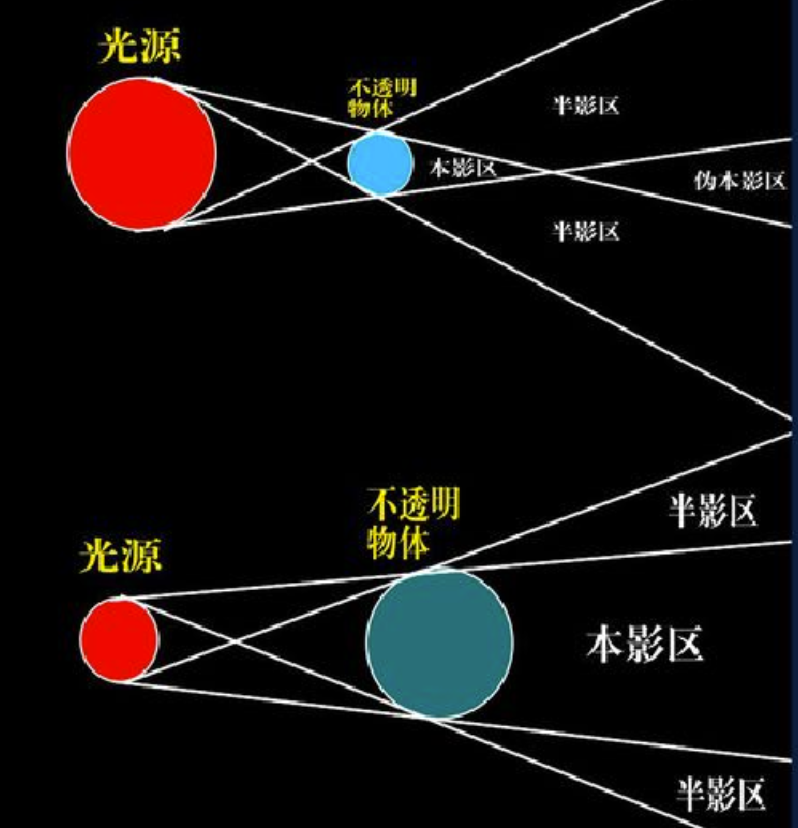

### Depth Pass算法计算shadow volume count:

看视线和光线的交点,和正面交+1,和背面交-1.

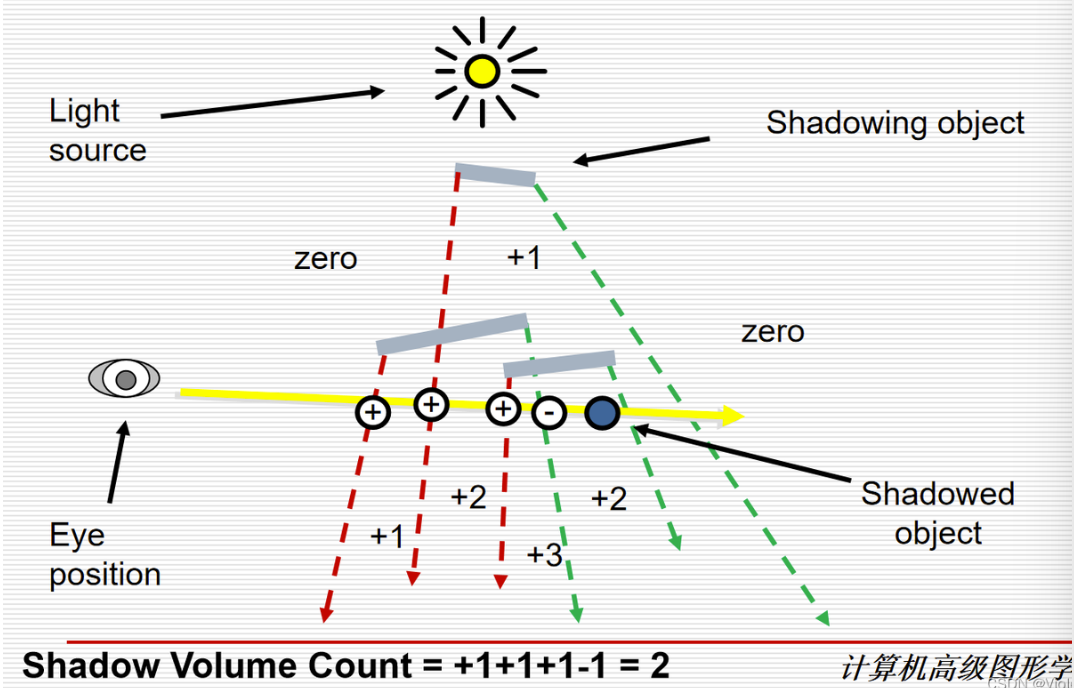

### Depth Fail算法

简单方法:画出视线和光线的交点,只看位置在A之后的光线.(被A遮挡的光线)如果与背后相交就+1,和正面相交就-1.(正好和pass相反计数)

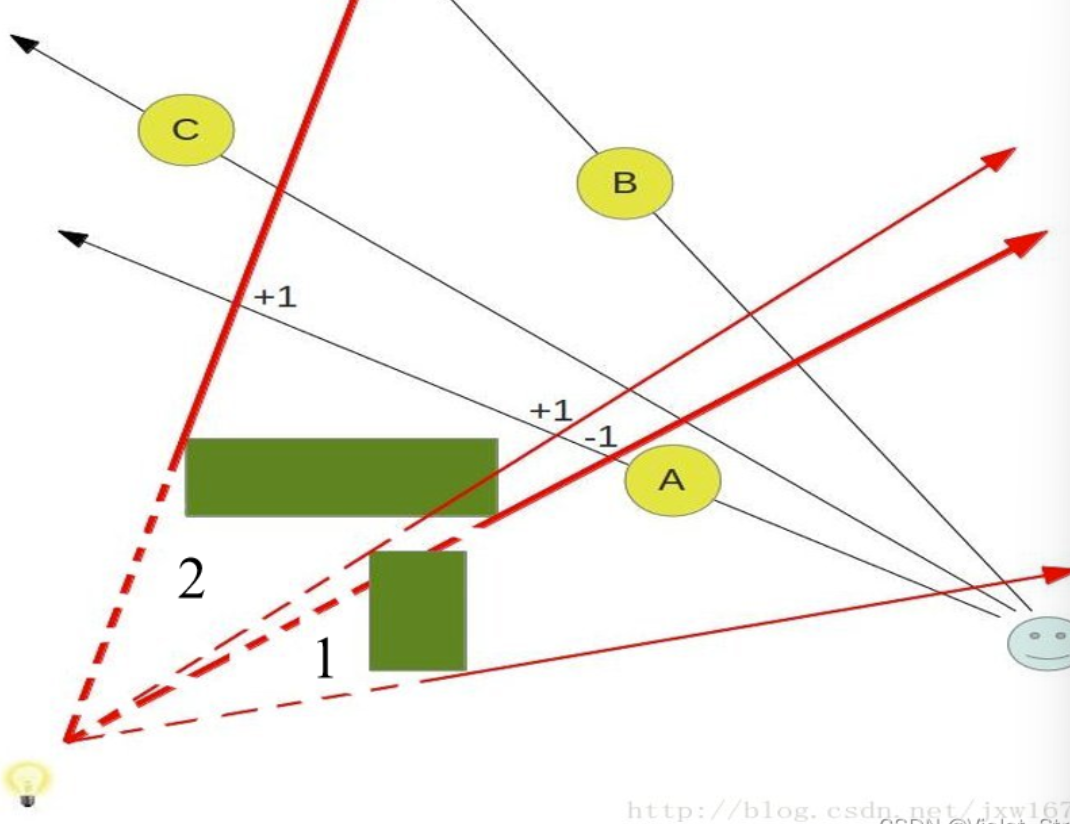

## 第十章 实时绘制加速技术

### 1.LOD(Level of Detail)技术

#### 基本思想:
- 根据物体在画面上的视觉重要性选取适当细节层次绘制该物体.
- 简化小对象物体/远处对象的多边形几何体

#### 离散LOD:
- 传统LOD:
  - 在预处理中分别为每个对象创建LOD.
  - 在运行时,根据对象的距离(或类似标准)选取每个对象的LOD.
- 由于LOD是以固定分辨率离线创建的,因此称为离散LOD.

- 优缺点:
  - LOD创建不需要受到实时渲染约束.
  - 运行时渲染只需要选取LOD.
  - 不适合剧烈的简化.
#### 连续LOD:
- 在运行时创建各个详细级别
- 更好的粒度 -> 平滑过渡

#### View-Dependent LOD解决了大物体渲染问题
#### Hierarchical LOD解决了小物体渲染的问题
### 2.网格压缩传输技术

- 场景绘制的速度受到场景中三角形数目的制约,在绘制一个三角形时,必须将其全部三个顶点的信息传送到图形硬件.
- 为避免同一顶点信息的重复传送,大多数图形API均采用三角形带和三角形扇等复合三角形结构进行传输.
- 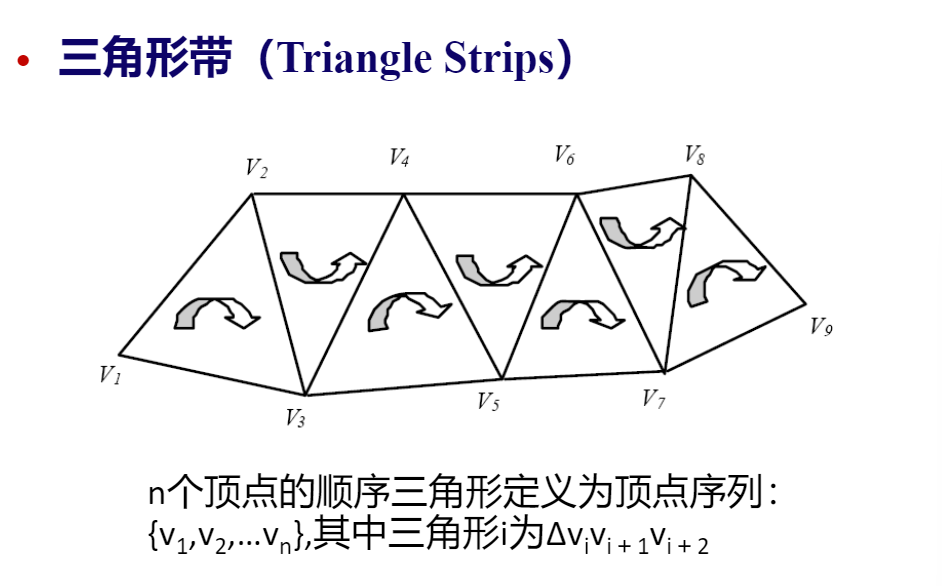
- 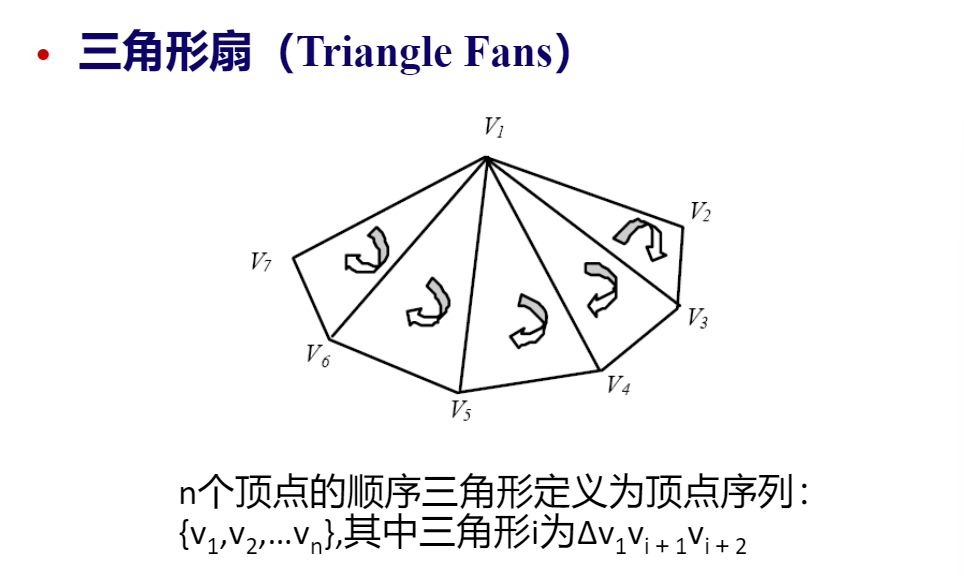
- 这样就把处理与传输m个三角形的代价从3m个顶点降低到了m+2个.

## 第十一章 OpenGL

### 简单图形绘制

- 点
  
~~~C++
glBegin(GL_POINTS);
glVertex3f(1.0,0.0,0.0);   //Vertex表面这是一个顶点
glVertex3f(1.0,1.0,0.0);   // 3表明坐标维数
glVertex3f(0.0,1.0,1.0);   // f表示坐标分量的数据类型是浮点数float
glEnd();
~~~

- 线

~~~C++
glBegin(GL_LINES);
glVertex2f(0.0,0.0);
glVertex2f(1.0,1.0);
glEnd();
~~~

- 三角形的绘制

~~~C++
glBegin(GL_TRIANGLES);
glVertex2f(0.0,0.0);
glVertex2f(1.0,1.0);
glVertex2f(0.5,1.0);
glEnd();
~~~

- 多边形的绘制

~~~C++
glBegin(GL_POLYGON);
glVertex2f();
glVertex2f();
glVertex2f();
glVertex2f();
glEnd();
~~~

- 矩形(Rectangle)

~~~C++
glRectf(x1,y1,x2,y2);
~~~

- 立方体(Cube)
~~~C++
auxWireCube(1.0);   //aux:库    Wire:表示绘制的是物体的边     Cube:表示物体是立方体   参数1.0:表示立方体的边长
// 通常以坐标原点为中心对称放置
~~~

- 球体(Sphere)
~~~C++
auxSolidSphere(1.0f);     //Solid:表示绘制的是物体的面    1.0f:半径为1.0,float类型
~~~

### 坐标变换

#### 模型观察变化
~~~C++
// 平移变换
void glTranslate{fd}(TYPE x,TYPE y,TYPE z);   //{fd}是占位符,表明函数由两个版本,取决于传入的参数数据类型float或double.TYPE对应GLfloat或者GLdouble
// 旋转 绕矢量(x,y,z)逆时针方向旋转指定角度angle
void glRotate{fd}{TYPE angle,TYPE x,TYPE y,TYPE z};
// 缩放变换
void glScale{fd}(TYPE x,TYPE y,TYPE z);  //xyz为对应的缩放因子
~~~

~~~C++
glMatrixMode(GL_MODVIEW); //要修改的是 模型视图矩阵
glLoadIdentity(); // 初始化
glMultMatrixf(N); //apply transformation N
                  //之后绘制的图形都会自动被应用以上变换
glBegin(GL_POINTS);
glVertex3f(v);   //这个点v会被应用变换N
glEnd();
~~~

#### 投影变换
~~~C++
glMatrixMode(GL_PROJECTION);      //接下来要操作的矩阵栈是 投影矩阵栈
glLoadIdentity();

//正交投影
void gluOrtho(GLdouble left,GLdouble right,GLdouble bottom,GLdouble top,GLdouble near,GLdouble far);
//定义了六个平面
//透视投影
void gluPerspective(GLdouble fovy,GLdouble aspect,GLdouble zNear,GLdouble zFar);
//fovy(filed of view y)Y轴方向的视野角度.
//aspect:宽高比:width/height.确保图像不被拉伸.
//znear,zfar:远近裁剪面距离.
~~~

#### 视口变换
~~~C++
void glViewport(GLint x,GLint y,GLsizei width,GLsizei height);
//注意:glViewport函数用于将归一化设备坐标映射到实际的屏幕坐标.
//GLint x,y:视口矩形左下角的xy坐标.以像素为单位.
//GLsizei width,height:视口矩形的宽度和高度,以像素为单位.

//比如,要完全覆盖一个宽度为800,高度为600的显示屏
glViewport(0,0,800,600);
~~~

### 简单光照场景

- Shading模式

~~~C++
void glShadeModel(GLenum mode);
//OpenGL支持两种:
//GL_FLAT
//GL_SMOOTH(主要是gouraud,目前不支持phong shading)
~~~

- 光照属性

~~~C++

glEnable(GL_LIGHT);//启动OpenGL的光照计算功能
glGetIntegerv(GL_MAX_LIGHTS); //查询OpenGL支持的最大光源数量.这个值在不同硬件或OpenGL版本中有所不同.
void glLightfv(GLenum light,GLenum pname,const GLfloat* params);//设置光源属性.
                                                                // light:要配置的光源id:GL_LIGHT0,GL_LIGHT1...
                                                                // pname:光源属性:GL_AMBIENT,GL_DIFFUSE,GL_SPECULAR
                                                                // params:(parameters)指向包含属性值(通常是3到4个浮点数)的数组的指针.例如光源颜色,位置坐标等.
glEnable(GL_LIGHTi);//启用特定的光源:i 从0到GL_MAX_LIGHTS  
~~~

- 颜色属性

~~~C++
glEnable(GL_COLOR_MATERIAL);  //启用颜色材质
glColorMaterial(GLenum face, GLenum mode); // 定义当前设置的颜色应该绑定到物体的:1.哪个面:GL_FRONT,GL_BACK,GL_FRONT_AND_BACK
                                           //                                2.哪个材质属性:GL_AMBIENT,GL_DIFFUSE
glColor3f(r,g,b);  //设置颜色
~~~


### 发光球体场景设置

~~~C++
#include <windows.h>
#include <GL/gl.h>
#include <GL/glu.h>
#include <GL/glaux.h>

...什么几把玩意,太难了把
~~~